In [19]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy.special import factorial
import matplotlib.cm as cm
from matplotlib.colors import Normalize
import math
from IPython.display import Latex

In [20]:
c=2.998*10**8 #in m/s
v_esc = 500*10**3/c 
v_E = 240*1000/c 
w_minus = 60*10**-3
w_plus = 20*10**-3
v0 = 230*1000/c
ratio=v_esc/v0
N0 = v0**3*np.pi*(np.sqrt(np.pi)*scipy.special.erf(ratio)-2*ratio*np.exp(-ratio**2))
dm_density = 0.4 #GeV/cm^3, plus minus 0.1
target_density = 1.31e24 #GeV/cm^3
Si_nucleus_mass = 931368088 #eV
f=70
V=0.543*5.064225

In [21]:
def reducedMass(m1, m2):
    return m1*m2/(m1+m2)

In [22]:
def getOmega(n,j):
    return n*w_minus+j*(w_plus-w_minus)

In [23]:
class NaturalAndSI_Conversion:
    def __init__(self):
        self.c=2.998*10**8
        self.planck = 6.626070e-34 #in J*s
        self.h_bar = self.planck/(2*np.pi)
        self.eV = 1.602176634e-19 #J
        self.electron_charge = 1.602176e-19 #C
    def massConversion(self, m, toSI=True):
        if toSI:
            return m*self.eV/(self.c**2)
        else:
            return m*self.c**2/self.eV
    def speedConversion(self,v, toSI=True):
        if toSI:
            return v*self.c
        else:
            return v/self.c
    def momentumConversion(self, p, toSI):
        return p*self.massConversion(1, toSI)*self.speedConversion(1,toSI)

# Calculation for the Mean Inverse Velocity

When $v_{min}<v_{esc}-v_E$:
$$\eta(v_{min})=\frac{v_0^2\pi}{2v_E N_0} (-4e^{-v_{esc}^2/v_0^2}v_E +\sqrt{\pi} v_0 [\text{Erf}(\frac{v_{min}+v_E}{v_0})-\text{Erf}(\frac{v_{min}-v_E}{v_0})]$$

When $v_{esc}-v_E<v_{min}<v_{esc}+v_E$:
$$\eta(v_{min})=\frac{v_0^2\pi}{2v_E N_0} (-2e^{-v_{esc}^2/v_0^2}(v_{esc}-v_{min}+v_E)+\sqrt{\pi}v_0 [\text{Erf}(\frac{v_{esc}}{v_0})-\text{Erf}(\frac{v_{min}-v_E}{v_0})])$$

Otherwise $\eta(v_{min})=0$

In [24]:
def inverseMeanFunction_sol1(v_min, m_chi, const):
    summ = np.sqrt(np.pi)*v0*(scipy.special.erf((v_min+v_E)/v0)-scipy.special.erf((v_min-v_E)/v0))
    summ -= 4*np.exp(-v_esc**2/v0**2)*v_E
    return summ*const

def inverseMeanFunction_sol2(v_min, m_chi, const):
    summ = np.sqrt(np.pi)*v0*(scipy.special.erf(v_esc/v0)-scipy.special.erf((v_min-v_E)/v0))
    summ -= 2*np.exp(-v_esc**2/v0**2)*(v_esc-v_min+v_E)
    return summ*const

def inverseMeanFunction(v_min, m_chi, const = v0**2*np.pi/(2*v_E*N0)):
    """
    Returns the inverse mean value for any given v_min.  
    Parameters:
        v_min: input velocity
        m_chi: mass of dark matter
        const: scaling value for graphing.  As a default, it gives the true scale of the equation
    """
    if v_min>v_esc+v_E:
        return 0
    elif v_min>v_esc-v_E:
        return inverseMeanFunction_sol2(v_min,m_chi, const)
    else: 
        return inverseMeanFunction_sol1(v_min,m_chi, const)

Now we the input from $v_{min}$ to q and $\omega$:

In [25]:
def get_vmin(q,w, m_chi):
    return w/q+q/(2*m_chi)

In [26]:
def inverseMeanFunction_fromq(q, w, m_chi, const=v0**2*np.pi/(2*v_E*N0)):
    return inverseMeanFunction(get_vmin(q,w,m_chi), m_chi, const)

Now we graph

In [27]:
m_chi = 20000
w = 0.01
q_range = np.linspace(1, m_chi*(v_esc+v_E)+np.sqrt(m_chi**2*(v_esc+v_E)**2)+10, 200)
eta = [inverseMeanFunction_fromq(q, w, m_chi) for q in q_range]

Inverse Mean Velocity as a function of q


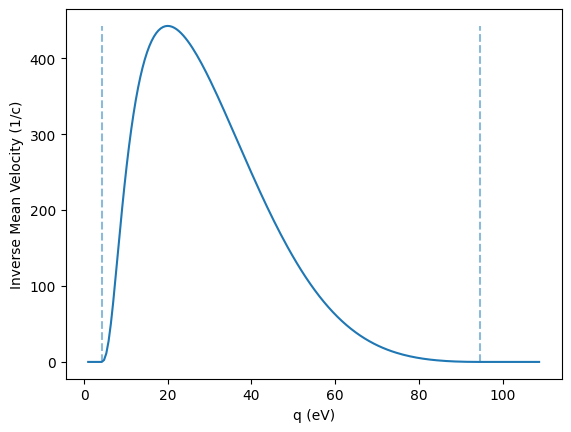

In [28]:
plt.plot(q_range, eta)
plt.vlines([m_chi*(v_esc+v_E)-np.sqrt(m_chi**2*(v_esc+v_E)**2-2*w*m_chi), 
            m_chi*(v_esc+v_E)+np.sqrt(m_chi**2*(v_esc+v_E)**2-2*w*m_chi)],0,max(eta), linestyles="dashed", alpha=0.5)
plt.ylabel("Inverse Mean Velocity (1/c)")
plt.xlabel("q (eV)")
print("Inverse Mean Velocity as a function of q")

# Structure Factor

Diagonal Term:
$$e^{-2W_d}(\frac{q^2}{4m})^n\frac{1}{j!(n-j)!(\omega_1^j \omega_2^{n-j})}$$

Off Diagonal Term:
$$(-1)^{n-j}e^{-2W_d}(\frac{q^2}{4m})^n\frac{\cos(qa)}{j!(n-j)!(\omega_1^j \omega_2^{n-j})}$$

In [29]:
def get_diag(n,j,q, m, w1, w2): 
    debye_waller = q**2 / (8*m) * (1/w1 +1/w2)
    return np.exp(-2*debye_waller) * (q**2/(4*m))**n / (math.factorial(j) * math.factorial(n-j) * (w1**j) * (w2**(n-j)))

def get_off_diag(n,j,q, m, w1, w2, a=0.543*5.064225): 
    debye_waller = q**2 / (8*m) * (1/w1 +1/w2)
    return (-1**(n-j)) * np.exp(-2*debye_waller) * np.cos(q*a) * (q**2/(4*m))**n / (math.factorial(j) * math.factorial(n-j) * (w1**j) * (w2**(n-j)))

# $\frac{\delta R}{\delta q}$

 $$R_\chi = \frac{\rho_\chi}{\rho_T m_\chi} \int \frac{q \, dq}{(2\pi)^2} \, d\omega \, \eta(v_{min}(q,\omega)) \cdot \frac{\pi \sigma(q)}{\mu_\chi^2}\cdot S(q,\omega)$$
  $$R_{\chi ,nj} = \frac{\rho_\chi \sigma}{4\pi \rho_T m_\chi \mu_\chi^2} \int q \, dq \, \eta(v_{min}(q,\omega_{nj})) \cdot S(q,\omega_{nj})$$
  $$\frac{\delta R}{\delta q}= \frac{\rho_\chi \sigma}{4\pi \rho_T m_\chi \mu_\chi^2} q\sum_n^\infty \sum_j^n \eta(v_{min}(q,\omega_{nj})) \cdot S(q,\omega_{nj})$$

In [30]:
def Rate_q_derivative_nj(q,n,j,m_chi, sigma=10**-40):
    const = (dm_density*sigma)/(4*np.pi*target_density*m_chi*reducedMass(m_chi, Si_nucleus_mass)**2)
    structure_factor = 2*np.pi*f**2/V*(get_diag(n,j,q,m_chi, w_plus, w_minus)+get_off_diag(n,j,q,m_chi,w_plus, w_minus))
    eta = inverseMeanFunction_fromq(q, n*w_minus+j*(w_plus-w_minus), m_chi)
    return const*q*structure_factor*eta

In [31]:
def Rate_q_derivative_n(q,n, m_chi, sigma=10**-40):
    rate =0
    for j in range(n+1):
        rate+=Rate_q_derivative_nj(q,n,j,m_chi, sigma)
    return rate

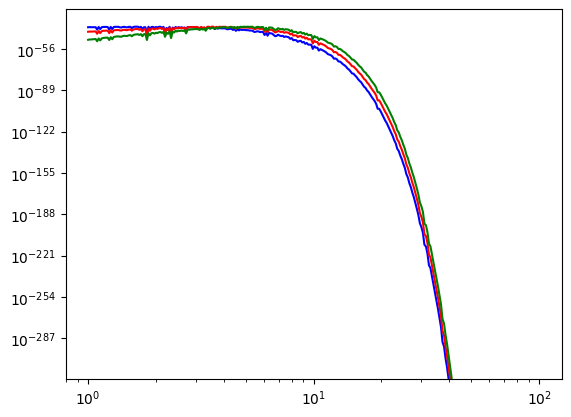

In [32]:
n_current=1
j_current=1
q_range = 10**np.linspace(3, 5, 300)
#rates1 = [Rate_q_derivative_nj(q,n_current,j_current,40*10**6, 1) for q in q_range]
#rates2 = [Rate_q_derivative_nj(q,1,0,40*10**6, 1) for q in q_range]
rates1 = [Rate_q_derivative_n(q,1,40*10**6, 1) for q in q_range]
rates2 = [Rate_q_derivative_n(q,5,40*10**6, 1) for q in q_range]
rates3 = [Rate_q_derivative_n(q,10,40*10**6, 1) for q in q_range]

plt.plot(q_range/1000, rates1, color="blue")
plt.plot(q_range/1000, rates2, color="red")
plt.plot(q_range/1000, rates3, color="green")

plt.yscale("log")
plt.xscale("log")

Text(0, 0.5, 'dR/dq')

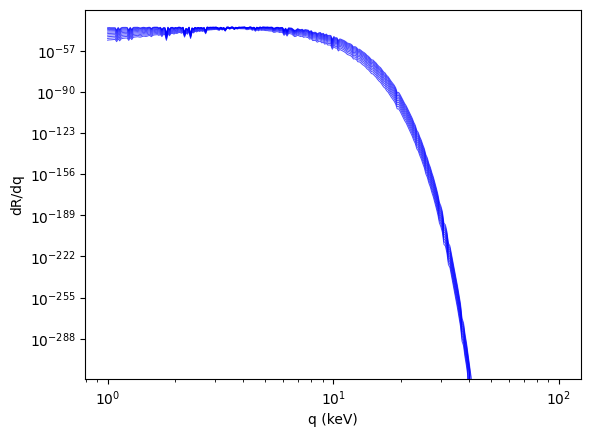

In [34]:
rates = [[Rate_q_derivative_n(q,n,40*10**6, 1) for q in q_range] for n in range(1,11)]
for n in range(10):
    plt.plot(q_range/1000, rates[n], color="blue", alpha=0.7, linewidth=0.7)
plt.yscale("log")
plt.xscale("log")

plt.xlabel("q (keV)")
plt.ylabel("dR/dq")

In [35]:
def Rate_q_derivative(q,n_max, m_chi, sigma=10**-42):
    rate =0
    for n in range(n_max+1):
        for j in range(n+1):
            rate+=Rate_q_derivative_nj(q,n,j,m_chi, sigma)
    return rate

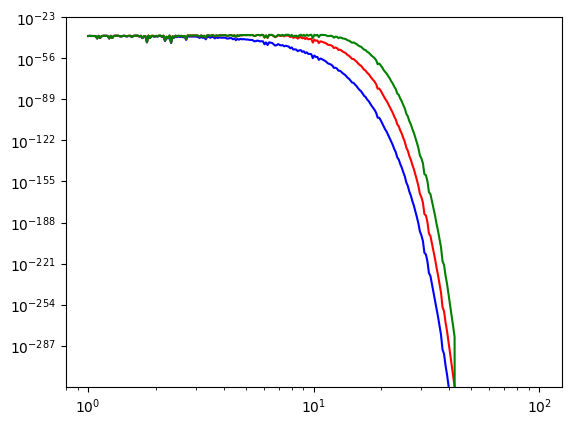

In [36]:
q_range = 10**np.linspace(3, 5, 300)
rates1 = [Rate_q_derivative(q,1,40*10**6, 1) for q in q_range]
rates2 = [Rate_q_derivative(q,20,40*10**6, 1) for q in q_range]
rates3=[Rate_q_derivative(q,50,40*10**6, 1) for q in q_range]

plt.plot(q_range/1000, rates1, color="blue")
plt.plot(q_range/1000, rates2, color="red")
plt.plot(q_range/1000, rates3, color="green")
plt.yscale("log")
plt.xscale("log")